# Transfer Learning with DenseNet121

This notebook is based on [episode 5](https://carpentries-lab.github.io/deep-learning-intro/5-transfer-learning.html) and demonstrates **transfer learning**: we take a DenseNet121 network pre-trained on ImageNet, freeze its weights, and add a small classification head for the Dollar Street 10-class task. This approach achieves strong accuracy with far less training data and compute than training from scratch.

> **Platform:** Tested on **UCL's Unified AI Platform** (5 CPUs, 64 GB RAM). Runs in any standard environment with the required dependencies installed.

> **Support:** Contact [ARC.Collaborations@ucl.ac.uk](mailto:ARC.Collaborations@ucl.ac.uk) for help with AI platforms, GPUs, or Carpentries training.

---

| Shortcut | Action |
|---|---|
| `Shift + Enter` | Run current cell, move to next |
| `Alt + Enter` | Run current cell, insert new cell below |
| `Ctrl + Shift + F9` | Restart kernel and run all cells |

## 1. System Information

In [1]:
import sys, platform
from datetime import datetime

print(f"Date/Time : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Python    : {sys.version}")
print(f"Platform  : {platform.platform()}")
print(f"Machine   : {platform.machine()}")

Date/Time : 2026-05-28 22:13:59
Python    : 3.11.10 | packaged by conda-forge | (main, Sep 30 2024, 18:08:57) [GCC 13.3.0]
Platform  : Linux-5.14.0-570.30.1.el9_6.x86_64-x86_64-with-glibc2.35
Machine   : x86_64


## 2. Platform Configuration

Set `PLATFORM` to `"unified-ai"` or `"colab"` to configure the data path automatically. Both platforms use identical code below this cell.

In [2]:
# ── Choose your platform ──────────────────────────────────────────────────────
PLATFORM = "unified-ai"   # options: "unified-ai" | "colab"
# ─────────────────────────────────────────────────────────────────────────────

import pathlib

if PLATFORM == "unified-ai":
    DATA_FOLDER = pathlib.Path('/home/jovyan/data/dataset_dollarstreet')
elif PLATFORM == "colab":
    DATA_FOLDER = pathlib.Path('/content/data/dataset_dollarstreet')
else:
    raise ValueError(f"Unknown platform '{PLATFORM}'. Choose 'unified-ai' or 'colab'.")

DATA_FOLDER.mkdir(parents=True, exist_ok=True)
print(f"Platform    : {PLATFORM}")
print(f"Data folder : {DATA_FOLDER}")

Platform    : unified-ai
Data folder : /home/jovyan/data/dataset_dollarstreet


## 3. Imports
All imports are collected here.

In [3]:
# Standard library
import time

# Numerical & visualisation
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ML / DL
import tensorflow
import sklearn
from tensorflow import keras
import tensorflow as tf

print("All packages imported successfully.")

I0000 00:00:1780006449.073618 1108682 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


All packages imported successfully.


## 4. Download Data

In [4]:
ZENODO_BASE = "https://zenodo.org/records/10970014/files"
for fname in ["train_images.npy", "train_labels.npy",
              "test_images.npy",  "test_labels.npy"]:
    !wget -nc -q -P {DATA_FOLDER} {ZENODO_BASE}/{fname}
    print(f"  {'OK' if (DATA_FOLDER / fname).exists() else 'MISSING':6}  {fname}")

  OK      train_images.npy
  OK      train_labels.npy
  OK      test_images.npy
  OK      test_labels.npy


## 5. Load & Normalise Data

In [5]:
train_images = np.load(DATA_FOLDER / 'train_images.npy')
val_images   = np.load(DATA_FOLDER / 'test_images.npy')
train_labels = np.load(DATA_FOLDER / 'train_labels.npy')
val_labels   = np.load(DATA_FOLDER / 'test_labels.npy')

print(f"train_images : {train_images.shape}  dtype={train_images.dtype}")
print(f"val_images   : {val_images.shape}")

# Rescale pixel values from [0, 255] to [0, 1]
train_images = train_images / 255.0
val_images   = val_images   / 255.0
print(f"\nPixel range after normalisation: [{train_images.min():.1f}, {train_images.max():.1f}]")

train_images : (878, 64, 64, 3)  dtype=int32
val_images   : (293, 64, 64, 3)

Pixel range after normalisation: [0.0, 1.0]


## 6. Build the Transfer Learning Model

**Architecture:**
```
Input (64×64×3)
  └─ Lambda: resize to 160×160  (DenseNet121 minimum input size)
       └─ DenseNet121 (frozen, ImageNet weights)
            └─ Flatten → BatchNorm → Dense(50, ReLU) → Dropout(0.5) → Dense(10)
```

Freezing the base model (`trainable=False`) means only the classification head is updated during training — far fewer parameters to optimise.

In [6]:
keras.utils.set_random_seed(2)

# Input
inputs = keras.Input(train_images.shape[1:])

# Upscale 64×64 → 160×160 (DenseNet121 expects at least 32×32; 160 gives better features)

method = tf.image.ResizeMethod.BILINEAR
upscale = keras.layers.Lambda(
  lambda x: tf.image.resize_with_pad(x, 160, 160, method=method))(inputs)

In [7]:
# Load DenseNet121 pre-trained on ImageNet; exclude the original classification head
base_model = keras.applications.DenseNet121(
    include_top=False,
    pooling='max',
    weights='imagenet',
    input_tensor=upscale,
    input_shape=(160, 160, 3),
)

# Freeze all base model weights — we only train the head
base_model.trainable = False
print(f"Base model parameters : {base_model.count_params():,} (all frozen)")

E0000 00:00:1780006475.623303 1108682 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Base model parameters : 7,037,504 (all frozen)


In [9]:
# Classification head
out = base_model.output
out = keras.layers.Flatten()(out)
out = keras.layers.BatchNormalization()(out)
out = keras.layers.Dense(units=50, activation='relu')(out)
out = keras.layers.Dropout(rate=0.5)(out)
out = keras.layers.Dense(units=10)(out)        # 10 classes; logits (no softmax)

model = keras.models.Model(inputs=inputs, outputs=out)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 160, 160,  │          0 │ input_layer[0][0] │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 166, 166,  │          0 │ lambda[0][0]      │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 80, 80,    │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 80, 80,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 80, 80,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 82, 82,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 40, 40,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 40, 40,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 40, 40,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 40, 40,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 40, 40,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 40, 40,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 40, 40,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 40, 40,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 40, 40,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 40, 40,    │          0 │ conv2_block2_0_b

 Total params: 7,093,360 (27.06 MB)

 Trainable params: 53,808 (210.19 KB)

 Non-trainable params: 7,039,552 (26.85 MB)

## 7. Compile & Train

We use early stopping on `val_accuracy` to avoid wasted training time.

In [10]:
model.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [11]:
early_stopper = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True   # revert to the epoch with best val_accuracy
)

In [12]:
start_time = time.time()

history = model.fit(
    x=train_images,
    y=train_labels,
    batch_size=128,
    epochs=10,
    callbacks=[early_stopper],
    validation_data=(val_images, val_labels)
)

elapsed = time.time() - start_time
print(f"\nTraining completed in {elapsed:.1f}s ({elapsed/60:.2f} min)")

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 75s 10s/step - accuracy: 0.1310 - loss: 2.8583 - val_accuracy: 0.1980 - val_loss: 3.8933
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 65s 10s/step - accuracy: 0.2688 - loss: 2.1975 - val_accuracy: 0.2457 - val_loss: 3.3251
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 71s 11s/step - accuracy: 0.3428 - loss: 1.8934 - val_accuracy: 0.2730 - val_loss: 2.7530
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 62s 9s/step - accuracy: 0.4499 - loss: 1.6234 - val_accuracy: 0.3242 - val_loss: 2.3547
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 67s 10s/step - accuracy: 0.5125 - loss: 1.4468 - val_accuracy: 0.3754 - val_loss: 2.0847
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 63s 9s/step - accuracy: 0.5490 - loss: 1.3360 - val_accuracy: 0.3959 - val_loss: 1.9315
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 64s 10s/step - accuracy: 0.6071 - loss: 1.1945 - val_accuracy: 0.4027 - val_loss: 1.8086
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 64s 9s/step - accuracy: 0.6105 - loss: 1.1409 - val_accuracy: 0.4403 - val_loss: 1.7113
Epo

## 8. Training History

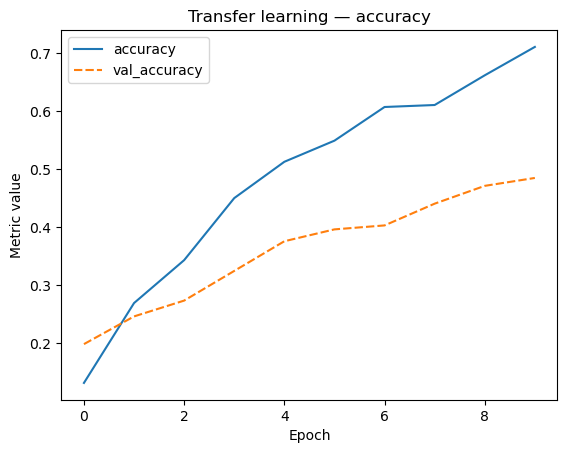

In [14]:
def plot_history(history, metrics):
    """Plot training and validation metrics over epochs."""    
    history_df = pd.DataFrame.from_dict(history.history)
    sns.lineplot(data=history_df[metrics])
    plt.xlabel("Epoch"); plt.ylabel("Metric value")

plot_history(history, ['accuracy', 'val_accuracy'])
plt.title("Transfer learning — accuracy")
plt.show()

## 9. Training Time Benchmarks

Observed wall-clock times for `model.fit(batch_size=128, epochs=10)` across different compute configurations (add your own row after running).

| Platform | CPUs | RAM | Time (s) | Time (min) |
|---|---|---|---|---|
| UCL Unified AI | 2 | 4 GB | 2441 | 40.7 |
| UCL Unified AI | 4 | 8 GB | 1257 | 20.9 |
| UCL Unified AI | 4 | 16 GB | 1311 | 21.9 |
| UCL Unified AI | 8 | 32 GB | 698 | 11.6 |
| UCL Unified AI | 8 | 64 GB | 735 | 11.4 |
| Google Colab (2 vCPU, ~12 GB) | 2 | 12 GB | 1325 | 22.1 |

## References

- Course: [Introduction to Deep Learning (Carpentries)](https://carpentries-lab.github.io/deep-learning-intro/)
- [Dollar Street dataset on Zenodo](https://zenodo.org/records/10970014)
- [DenseNet121 — Keras Applications](https://keras.io/api/applications/densenet/)
- [Transfer learning guide — TensorFlow](https://www.tensorflow.org/guide/keras/transfer_learning)
- [DenseNet paper (Huang et al. 2017)](https://arxiv.org/abs/1608.06993)